In [56]:
include("CRD_STA.jl")
include("Fun.jl")
using LinearAlgebra
using NonlinearEigenproblems
using DelimitedFiles
using DifferentialEquations
using Plots

In [57]:
function BF(N_cheb,Ro,Tw,Mr)
    gamma = 1.4
    sigma = 0.72
    Co = 2 - Ro - Ro^2
    u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    return F,G,H,T,rho,x,lam,kappa,D,D2
end
function eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
    cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
    L0,L1,L2 = assemble_mat(cof,D,D2,be,omega)
    nep = PEP([L0,L1,L2]); 
    eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-12)
    # eigval = conj(eigval)
    return cof,eigval,eigvec
end
function integral(x,y)
    inte_progress =  zeros(ComplexF64,length(x),1)
    for i = 1 : length(x)
        inte_progress[i] = x[1:i,1]' * y[1:i,1]
    end
    return inte_progress
end
function mat_diff(A,B,N_cheb)
    block_size = N_cheb + 1
    nblock = 5
    C = zeros(ComplexF64,block_size*nblock,block_size*nblock)
    for i = 0 : nblock - 1
        for j = 0 : nblock - 1
        C[1+block_size*i:block_size*(i+1),1+block_size*j:block_size*(j+1)] = (B * A[1+block_size*i:block_size*(i+1),1+block_size*j:block_size*(j+1)])
        end
    end

    return C'
end
function eig_full(eigvec,N_cheb,num)
    N = N_cheb + 1
    eigvec = eigvec[:,num]
    insert!(eigvec,5N-8,0im)
    insert!(eigvec,4N-6,0im)
    insert!(eigvec,4N-6,0im)
    insert!(eigvec,3N-4,0im)
    insert!(eigvec,3N-4,0im)
    insert!(eigvec,2N-2,0im)
    insert!(eigvec,2N-2,0im)
    insert!(eigvec,N,0im)
    insert!(eigvec,N,0im)
    rho = eigvec[1:N]
    u = eigvec[N+1:2N]
    v = eigvec[2N+1:3N]
    w = eigvec[3N+1:4N]
    T = eigvec[4N+1:5N]
    return eigvec,(rho,u,v,w,T)
end

eig_full (generic function with 1 method)

In [58]:
function Bi_linear(C,H1_A,vec_A)
    q_all = []
    for i = 1 : size(C.vectors,2)
        Q = (vec_A') * (H1_A' * C.vectors[:,i])
        q_all = [q_all ; Q]
    end 
    ind = findmax(abs.(q_all))
    Q = q_all[ind[2]]
    return q_all,Q,C.values[ind[2]]
end

Bi_linear (generic function with 1 method)

In [59]:
N_cheb = 99
Ro = -1
Tw = 1
Mr = 0.3
gamma = 1.4
sigma = 0.72
Co = 2-Ro-Ro^2
F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)

┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/TZ9Rx/src/integrator_interface.jl:686
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/TZ9Rx/src/integrator_interface.jl:686
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/TZ9Rx/src/integrator_interface.jl:686
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/TZ9Rx/src/integrator_interface.jl:686
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/TZ9Rx/src/integrator_interface.jl:686
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/TZ9Rx/src/integrator_interface.jl:686
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/TZ9Rx/src/integrator_interface.jl:686
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBas

([0.0; 0.00028248111788138077; … ; 1.3877773458350247e-31; 1.3877773458350247e-31;;], [0.0; -0.00034117928752682233; … ; -1.0; -1.0;;], [6.509293848336945e-27; -1.5650872874911616e-7; … ; -0.8844741107336918; -0.8844741107336918;;], [1.0; 1.0000046578758743; … ; 0.9999999999954216; 0.9999999999954216;;], [1.0; 0.9999953421458214; … ; 1.0000000000045786; 1.0000000000045786;;], [0.0; 0.0005539326468201291; … ; 30.0; 30.0;;], [-0.6666666666666666; -0.6666697719172495; … ; -0.6666666666636143; -0.6666666666636143;;], [1.3888888888888888; 1.3888953581609365; … ; 1.38888888888253; 1.38888888888253;;], [-2970.151515151124 3611.390030573762 … -0.9093198110834142 0.45454545454545453; -902.4262223900014 451.0994992567002 … 0.45456220808173375 -0.2272238764335357; … ; 4.436834640202506e-8 -8.875904163768224e-8 … -8.80829037817145e-5 0.00017621017590984625; -0.0 0.0 … -0.0 0.0], [5.295001504873778e6 -8.41357312149442e6 … 5384.226905905448 -2691.424943501555; 2.444105391034474e6 -3.4945616842321446

In [60]:
n = 32
num = 1
R = 320
omega = 0/R
be = n/R
Ma = Mr/R
cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
L0_raw,L1_raw,L2_raw= assemble_mat(cof,D,D2,be,omega)
L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb)
nep = PEP([L0,L1,L2]);
eigval,eigvec = iar(nep, σ = 0.5, neigs = 1 ,maxit = 500 , tol=1e-13)
vel_full,vel = eig_full(eigvec,N_cheb,1)
A0_raw = cof.D1' + (im * be * cof.B)' - (im * omega * cof.Ta)' - (be^2 * cof.Vyy)' - cof.dC' - (im *be*cof.dVyz)' + cof.d2Vzz' - (cof.C + im * be * cof.Vyz - 2 * cof.dVzz)' * kron(I(5),D) + cof.Vzz' * kron(I(5),D2)
A1_raw = (im * cof.A)' - (be * cof.Vxy)' - (im * cof.dVxz)' - (im * cof.Vxz)' * kron(I(5),D) 
A2_raw = -cof.Vxx'
A0,A1,A2 = boudary_condition(A0_raw,A1_raw,A2_raw,N_cheb)
nep = PEP([A0,A1,A2]); 
eigval_A,eigvec_A = iar(nep,σ = 0.5, neigs = 1 ,maxit = 500,tol=1e-12)
vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1)
@show eigval,eigval_A 

(eigval, eigval_A) = (ComplexF64[0.5101732059586321 + 0.00277771319364447im], ComplexF64[0.5101733271180035 - 0.0027777999317911343im])


(ComplexF64[0.5101732059586321 + 0.00277771319364447im], ComplexF64[0.5101733271180035 - 0.0027777999317911343im])

In [73]:
n = 32
num = 1
R = 320
omega = 0/R 
be = n/R
Ma = Mr/R
cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
# L0_raw,L1_raw,L2_raw= assemble_mat(cof,D,D2,be,omega)
L0_raw,L1_raw,L2_raw= Spatial_mode_BEK1(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2)
L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb)
Zero = zeros(size(L0,1),size(L0,2))
eye = I
H0 = [Zero eye;L0 L1]
H1 = [eye Zero; Zero -L2]
H0_A = [L0' L1';Zero -eye]
H1_A = [Zero -L2'; -eye Zero]
C = eigen(H0_A',H1_A')
val = filter(x -> abs(imag(x)) < 0.05 && 0.1<abs(real(x))<1, C.values)
C_A = eigen(H0_A,H1_A)
val_A = filter(x -> abs(imag(x)) < 0.05 && 0.1<abs(real(x))<1, C_A.values)
index = findall(C.values .== val[1])
index_A = findall(C_A.values .== val_A[1])
vec_L = C.vectors[:,index[1]]./findmax(abs.(C.vectors[:,index[1]]))[1]
vec_A = C_A.vectors[:,index_A[1]]./findmax(abs.(C_A.vectors[:,index_A[1]]))[1]
# vec_L = C.vectors[:,index[1]]
# vec_A = C_A.vectors[:,index_A[1]]
vec_half = vec_L[1:5*N_cheb-4,1]
vec_A_half = vec_A[1:5*N_cheb-4,1]
vel_full,vel = eig_full(vec_half,N_cheb,1)
vel_full_A,vel_A = eig_full(vec_A_half,N_cheb,1)
# Q = (vec_A') * (H1_A' * vec_L)
q_all,Q,target = Bi_linear(C,H1_A,vec_A)
@show val,val_A,target

(val, val_A, target) = (ComplexF64[0.5101733263745455 + 0.002777800917519481im], ComplexF64[0.5101733356212119 - 0.0027777983992044886im], 0.5101733263745455 + 0.002777800917519481im)


(ComplexF64[0.5101733263745455 + 0.002777800917519481im], ComplexF64[0.5101733356212119 - 0.0027777983992044886im], 0.5101733263745455 + 0.002777800917519481im)

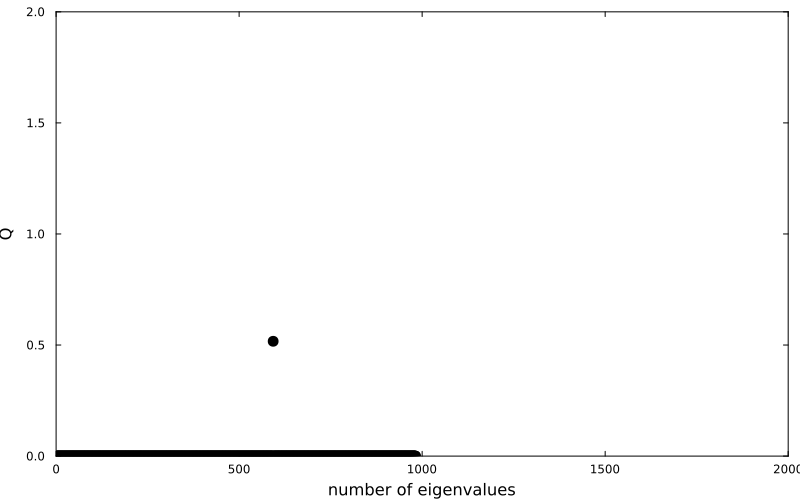

In [75]:
scatter(abs.(q_all),xlims=[0,2000],ylims=[0,2],size=(800,500),markersize=abs.(6),mc=:black,grid=false,label=false ,framestyle=:box,xlabel="number of eigenvalues", ylabel="Q")

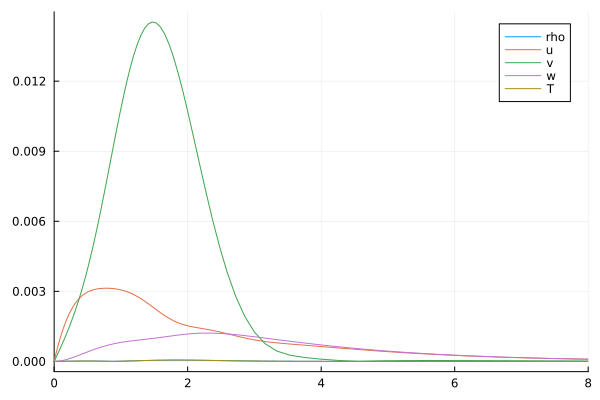

In [76]:
plot(z,abs.(vel[1]),label = "rho",xlims=[0,8]) 
plot!(z,abs.(vel[2]),label = "u")
plot!(z,abs.(vel[3]),label = "v")
plot!(z,abs.(vel[4]),label = "w")
plot!(z,abs.(vel[5]),label = "T") 

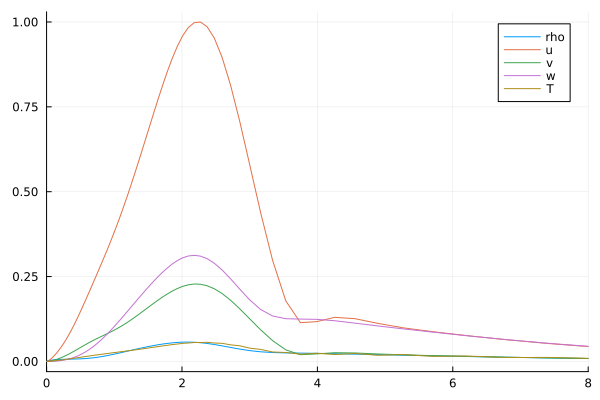

In [77]:
plot(z,abs.(vel_A[1]),label = "rho",xlims=[0,8]) 
plot!(z,abs.(vel_A[2]),label = "u")
plot!(z,abs.(vel_A[3]),label = "v")
plot!(z,abs.(vel_A[4]),label = "w")
plot!(z,abs.(vel_A[5]),label = "T") 

In [78]:
N_cheb = 99
Ro = -1
Tw = 1
Mr = 0.3
gamma = 1.4
sigma = 0.72
Co = 2-Ro-Ro^2
n = 32
num = 1
R = 100
omega = 0/R
be = n/R
Ma = Mr/R
F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)

┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/TZ9Rx/src/integrator_interface.jl:686
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/TZ9Rx/src/integrator_interface.jl:686
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/TZ9Rx/src/integrator_interface.jl:686
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/TZ9Rx/src/integrator_interface.jl:686
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/TZ9Rx/src/integrator_interface.jl:686
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/TZ9Rx/src/integrator_interface.jl:686
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/TZ9Rx/src/integrator_interface.jl:686
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBas

([0.0; 0.00028248111788138077; … ; 1.3877773458350247e-31; 1.3877773458350247e-31;;], [0.0; -0.00034117928752682233; … ; -1.0; -1.0;;], [6.509293848336945e-27; -1.5650872874911616e-7; … ; -0.8844741107336918; -0.8844741107336918;;], [1.0; 1.0000046578758743; … ; 0.9999999999954216; 0.9999999999954216;;], [1.0; 0.9999953421458214; … ; 1.0000000000045786; 1.0000000000045786;;], [0.0; 0.0005539326468201291; … ; 30.0; 30.0;;], [-0.6666666666666666; -0.6666697719172495; … ; -0.6666666666636143; -0.6666666666636143;;], [1.3888888888888888; 1.3888953581609365; … ; 1.38888888888253; 1.38888888888253;;], [-2970.151515151124 3611.390030573762 … -0.9093198110834142 0.45454545454545453; -902.4262223900014 451.0994992567002 … 0.45456220808173375 -0.2272238764335357; … ; 4.436834640202506e-8 -8.875904163768224e-8 … -8.80829037817145e-5 0.00017621017590984625; -0.0 0.0 … -0.0 0.0], [5.295001504873778e6 -8.41357312149442e6 … 5384.226905905448 -2691.424943501555; 2.444105391034474e6 -3.4945616842321446

In [81]:
function Q_cacu(L0,L1,L2,N_cheb)
    Zero = zeros(size(L0,1),size(L0,2))
    eye = I
    H0_A = [L0' L1';Zero -eye]
    H1_A = [Zero -L2'; -eye Zero]
    C = eigen(H0_A',H1_A')
    val = filter(x -> abs(imag(x)) < 0.05 && 0.1<abs(real(x))<1, C.values)
    C_A = eigen(H0_A,H1_A)
    val_A = filter(x -> abs(imag(x)) < 0.05 && 0.1<abs(real(x))<1, C_A.values)
    index = findall(C.values .== val[1])
    index_A = findall(C_A.values .== val_A[1])
    vec_L = C.vectors[:,index[1]]./findmax(abs.(C.vectors[:,index[1]]))[1]
    vec_A = C_A.vectors[:,index_A[1]]./findmax(abs.(C_A.vectors[:,index_A[1]]))[1]
    vec_half = vec_L[1:5*N_cheb-4,1]
    vec_A_half = vec_A[1:5*N_cheb-4,1]
    vel_full,vel = eig_full(vec_half,N_cheb,1)
    vel_full_A,vel_A = eig_full(vec_A_half,N_cheb,1)
    # eigvec_L = [vec_half ; val.* vec_half]
    # eigvec_L = eigvec_L ./findmax(abs.(eigvec_L))[1]
    Q = (vec_A') * (H1_A' * vec_L)
    return Q,vel,val
end

Q_cacu (generic function with 1 method)

In [83]:
coff = [0 0 0 0]
for R = 310 : 1 : 340
    be = 32/R
    Ma = Mr/R
    cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
    L0_raw,L1_raw,L2_raw = assemble_mat(cof,D,D2,be,omega)
    L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb)
    Q,vel,eigval = Q_cacu(L0,L1,L2,N_cheb)
    # x0 = R
    # u_wall = -(D*F)[1] * exp(-eigval[1] * (im* x0 + 2 * eigval[1]))
    # v_wall = -(D*G)[1] * exp(-eigval[1] * (im* x0 + 2 * eigval[1]))
    # w_wall = 0
    # rho_wall = -(D*rho)[1] * exp(-eigval[1] * (im* x0 + 2 * eigval[1]))
    # T_wall = -(D*T)[1] * exp(-eigval[1] * (im* x0 + 2 * eigval[1]))
    rho_wall = -(D*rho)[1]
    u_wall = -(D*F)[1]
    v_wall = -(D*G)[1]
    w_wall = 0
    T_wall = -(D*T)[1]
    item_1 = 0
    item_2 = rho_wall * (D*vel[2])[1] * u_wall
    item_3 = rho_wall * (D*vel[3])[1] * v_wall
    item_4 = -rho_wall^2 * (T_wall/sigma) * (D*vel[5])[1] * T_wall
    BC = item_1 + item_2 + item_3 + item_4
    Cr = abs(-im * BC/Q)
    coff = [coff;[R Cr abs(Q) abs(BC)]]
    writedlm("Cr_lof.dat",coff[2:end,:])
end


In [ ]:
coff = [0 0 0 0]
for R = 300 : 2 : 340
    be = 32/R
    Ma = Mr/R
    cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
    L0_raw,L1_raw,L2_raw = assemble_mat(cof,D,D2,be,omega)
    L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb)
    nep = PEP([L0,L1,L2]); 
    eigval,eigvec = iar(nep, σ = 0.5, neigs = 1,maxit = 500,tol=1e-12)
    vel_full,vel = eig_full(eigvec,N_cheb,1)
    A0_raw = cof.D1' + (im * be * cof.B)' - (im * omega * cof.Ta)' - (be^2 * cof.Vyy)' - cof.dC' - (im *be*cof.dVyz)' + cof.d2Vzz' - (cof.C + im * be * cof.Vyz - 2 * cof.dVzz)' * kron(I(5),D) + cof.Vzz' * kron(I(5),D2)
    A1_raw = (im * cof.A)' - (be * cof.Vxy)' - (im * cof.dVxz)' - (im * cof.Vxz)' * kron(I(5),D) 
    A2_raw = -cof.Vxx'
    A0,A1,A2 = boudary_condition(A0_raw,A1_raw,A2_raw,N_cheb)
    nep = PEP([A0,A1,A2]); 
    eigval_A,eigvec_A = iar(nep,σ = 0.5, neigs = 1 ,maxit = 500,tol=1e-16)
    vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1)

    Q,a1,a2= Q_cacu(L0,L1,L2,N_cheb)
    # Q = (eigvec_A[:,1]') * ((L1 + (eigval[1]- eigval_A[1]) * L2) * eigvec[:,1])
    # x0 = R
    # u_wall = -(D*F)[1] * exp(-eigval[1] * (im* x0 + 2 * eigval[1]))
    # v_wall = -(D*G)[1] * exp(-eigval[1] * (im* x0 + 2 * eigval[1]))
    # w_wall = 0
    # rho_wall = -(D*rho)[1] * exp(-eigval[1] * (im* x0 + 2 * eigval[1]))
    # T_wall = -(D*T)[1] * exp(-eigval[1] * (im* x0 + 2 * eigval[1]))
    rho_wall = (D*rho)[1]
    u_wall = (D*F)[1]
    v_wall = (D*G)[1]
    w_wall = 0
    T_wall = (D*T)[1]
    item_1 = R * rho_wall * vel_A[1][1] * v_wall
    item_2 = (Tw) * (D*vel_A[2])[1] * u_wall
    item_3 = (3Tw/4) * (D*vel_A[3])[1] * v_wall
    item_4 = (Tw/gamma) * (D*vel_A[5])[1] * T_wall
    BC = item_1 + item_2 + item_3
    Cr = abs(-im * BC/Q)
    coff = [coff;[R Cr abs(Q) abs(BC)]]
    writedlm("Cr_lof.dat",coff[2:end,:])
end

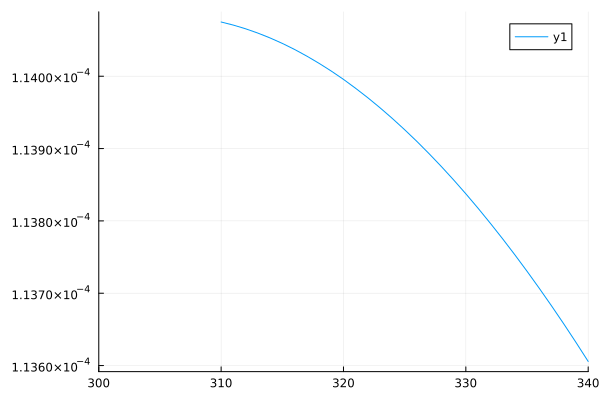

In [84]:
plot(real(coff[2:end,1]),real(coff[2:end,2]),xlims=[300,340])
# plot!(real(coff[2:end,1]),abs.(coff[2:end,3]))